# Cuaderno 2 — Construcción de features y variable objetivo

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento  
**Autores:** Andrea Meneses · Juan Ramos  
**Universidad EAFIT · 2026**

---

## Objetivo

Transformar los datos crudos descargados en el Cuaderno 1 en un dataset listo para el modelo de machine learning. Este proceso involucra cinco etapas:

1. **Filtrado de registros**: separar registros trimestrales puros de registros acumulados
2. **Destrimestralización**: recuperar FCF trimestral a partir de reportes acumulados
3. **Transformación de formato**: pasar de formato largo a formato ancho (pivot)
4. **Construcción de la variable objetivo Y**: definir qué empresa alcanza el breakeven
5. **Ingeniería de features**: crear variables derivadas con mayor poder predictivo

## Decisiones metodológicas clave

- **Variable objetivo:** Y=1 si el FCF operativo promedio de los próximos 4 trimestres es positivo, Y=0 si no. Se usa el promedio (no el máximo) para capturar breakeven sostenido, no puntual.
- **Filtro de universo:** solo se incluyen trimestres donde la empresa tenía FCF operativo negativo — la pregunta de investigación aplica únicamente a empresas que hoy queman caja.
- **Tratamiento de outliers:** winsorización al percentil 1-99, no eliminación. Esto preserva los casos extremos como información válida para el modelo.

## 1. Configuración inicial

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Identidad visual del proyecto
juan_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    """Aplica el estilo visual estándar del proyecto a un eje.
    orientacion='vertical'   -> grid horizontal (barras verticales o histogramas)
    orientacion='horizontal' -> grid vertical   (barras horizontales)
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.yaxis.grid(True,  linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["left"].set_visible(True)
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True,  linestyle="-", color=juan_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# Cargar datos crudos
df = pd.read_csv("../datos/crudos/variables_financieras_sec.csv")
df["start"] = pd.to_datetime(df["start"])
df["end"]   = pd.to_datetime(df["end"])
df["duracion_dias"] = (df["end"] - df["start"]).dt.days

print(f"Dataset cargado: {df.shape}")
print(f"Empresas: {df['ticker'].nunique()}")
print(f"Variables: {df['variable'].nunique()}")

Dataset cargado: (513807, 13)
Empresas: 343
Variables: 20


## 2. Análisis de duración de registros

La SEC EDGAR reporta algunas variables de forma acumulada año a año. Por ejemplo, el FCF del Q3 puede aparecer como el acumulado Q1+Q2+Q3, no solo el trimestre. Para el modelo necesitamos valores trimestrales puros.

Calculamos la duración en días entre `start` y `end` de cada registro para identificar si es:
- **~90 días**: trimestre puro ✓
- **~180 días**: dos trimestres acumulados
- **~270 días**: tres trimestres acumulados
- **~365 días**: año completo

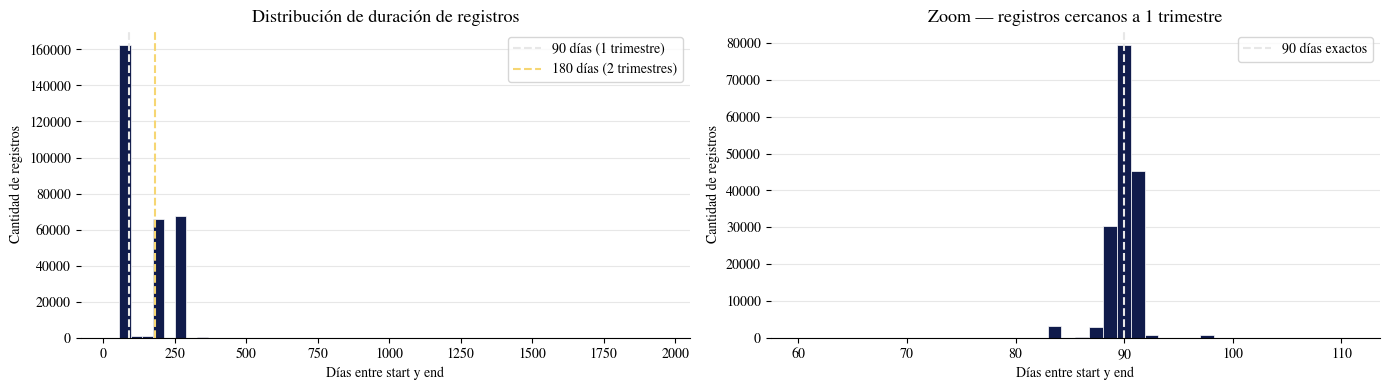

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    estilo_ax(ax, "vertical")

# Gráfico 1 — distribución completa
axes[0].hist(df["duracion_dias"].dropna(), bins=50,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[0].axvline(90,  color=juan_colors[3], linewidth=1.5, linestyle="--", label="90 días (1 trimestre)")
axes[0].axvline(180, color=juan_colors[5], linewidth=1.5, linestyle="--", label="180 días (2 trimestres)")
axes[0].set_title("Distribución de duración de registros", fontfamily=FUENTE, fontsize=13)
axes[0].set_xlabel("Días entre start y end", fontfamily=FUENTE)
axes[0].set_ylabel("Cantidad de registros", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE})

# Gráfico 2 — zoom en trimestres puros
df_zoom = df[df["duracion_dias"].between(60, 120)]
axes[1].hist(df_zoom["duracion_dias"].dropna(), bins=40,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].axvline(90, color=juan_colors[3], linewidth=1.5, linestyle="--", label="90 días exactos")
axes[1].set_title("Zoom — registros cercanos a 1 trimestre", fontfamily=FUENTE, fontsize=13)
axes[1].set_xlabel("Días entre start y end", fontfamily=FUENTE)
axes[1].set_ylabel("Cantidad de registros", fontfamily=FUENTE)
axes[1].legend(prop={"family": FUENTE})

plt.tight_layout()
plt.show()

## 3. Filtrado de registros trimestrales

Aplicamos dos estrategias de filtrado según el tipo de variable:

**Variables de flujo** (FCF, ingresos, utilidades): filtramos por duración entre 80 y 100 días — captura todos los trimestres reales sin incluir acumulados.

**Variables de balance** (caja, activos, pasivos): el balance no tiene `start` porque es una foto en un momento dado, no un flujo. Se filtra por el campo `fp` (fiscal period) que indica Q1, Q2, Q3, Q4.

In [57]:
variables_balance = [
    "activos_corrientes", "activos_totales", "caja",
    "cuentas_por_cobrar", "cuentas_por_pagar",
    "deuda_largo_plazo", "inventario", "pasivos_corrientes"
]

# Variables de flujo — duración trimestral pura
df_trimestral = df[
    (~df["variable"].isin(variables_balance)) &
    (df["duracion_dias"].between(80, 100))
].copy()

# Variables de balance — por período fiscal
df_balance = df[
    (df["variable"].isin(variables_balance)) &
    (df["fp"].isin(["Q1", "Q2", "Q3", "Q4"]))
].copy()

print(f"Variables de flujo (trimestral puro): {len(df_trimestral):,} registros — {df_trimestral['variable'].nunique()} variables")
print(f"Variables de balance (por período):   {len(df_balance):,} registros — {df_balance['variable'].nunique()} variables")

Variables de flujo (trimestral puro): 163,181 registros — 12 variables
Variables de balance (por período):   214,896 registros — 8 variables


## 4. Destrimestralización del FCF operativo

El FCF operativo es la variable más importante del modelo, pero la SEC lo reporta principalmente de forma acumulada. Con el filtro de 80-100 días solo recuperamos 9.272 de los 27.016 registros disponibles.

Para recuperar los registros restantes aplicamos **destrimestralización**: calculamos el valor trimestral puro restando el acumulado del período anterior.

- Q1 puro = Q1 acumulado (no hay período anterior)
- Q2 puro = Q2 acumulado − Q1 acumulado
- Q3 puro = Q3 acumulado − Q2 acumulado
- Q4 puro = Q4 acumulado − Q3 acumulado

In [58]:
fcf_raw = df[df["variable"] == "fcf_operativo"].copy()

# Separar trimestral puro y acumulado
fcf_puro      = fcf_raw[fcf_raw["duracion_dias"].between(80, 100)].copy()
fcf_acumulado = fcf_raw[~fcf_raw["duracion_dias"].between(80, 100)].copy()

# Destrimestralizar: restar acumulado del período anterior
fcf_acumulado = fcf_acumulado.sort_values(["ticker", "fy", "end"]).copy()
fcf_acumulado["val_anterior"]   = fcf_acumulado.groupby(["ticker", "fy"])["val"].shift(1)
fcf_acumulado["val_trimestral"] = fcf_acumulado["val"] - fcf_acumulado["val_anterior"]

# Q1: el acumulado ya es el trimestral puro (no hay período anterior)
mask_q1 = fcf_acumulado["val_anterior"].isna()
fcf_acumulado.loc[mask_q1, "val_trimestral"] = fcf_acumulado.loc[mask_q1, "val"]

fcf_destrimestralizado = fcf_acumulado.dropna(subset=["val_trimestral"]).copy()
fcf_destrimestralizado["val"] = fcf_destrimestralizado["val_trimestral"]
fcf_destrimestralizado = fcf_destrimestralizado.drop(
    columns=["val_anterior", "val_trimestral"], errors="ignore"
)

fcf_completo = pd.concat([fcf_puro, fcf_destrimestralizado], ignore_index=True)

print(f"FCF puro (trimestral directo):   {len(fcf_puro):,}")
print(f"FCF destrimestralizado:          {len(fcf_destrimestralizado):,}")
print(f"FCF total recuperado:            {len(fcf_completo):,}")

FCF puro (trimestral directo):   9,272
FCF destrimestralizado:          17,744
FCF total recuperado:            27,016


## 5. Consolidación del dataset limpio

Combinamos las variables de flujo, las de balance y el FCF destrimestralizado en un único dataset.

Shape final: 395,821 registros
Empresas: 343
Variables: 20
Guardado: variables_limpias.csv


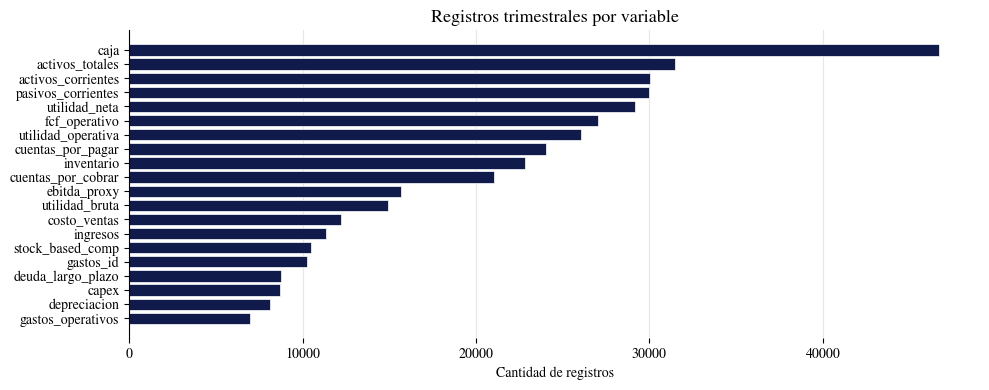

In [59]:
# Remover FCF del dataset de flujo (usamos la versión destrimestralizada completa)
df_flujo_sin_fcf = df_trimestral[df_trimestral["variable"] != "fcf_operativo"].copy()

# Consolidar
df_limpio = pd.concat([df_flujo_sin_fcf, df_balance, fcf_completo], ignore_index=True)

# Guardar datos limpios
df_limpio.to_csv("../datos/crudos/variables_limpias.csv", index=False)

print(f"Shape final: {len(df_limpio):,} registros")
print(f"Empresas: {df_limpio['ticker'].nunique()}")
print(f"Variables: {df_limpio['variable'].nunique()}")
print("Guardado: variables_limpias.csv")

# Gráfico — registros por variable
conteo = df_limpio["variable"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
estilo_ax(ax, "horizontal")
ax.barh(conteo.index, conteo.values, color=juan_colors[0], edgecolor="white", linewidth=0.5)
ax.set_title("Registros trimestrales por variable", fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Cantidad de registros", fontfamily=FUENTE)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

## 6. Transformación a formato ancho (pivot)

El modelo de machine learning requiere que cada fila sea una observación completa: una empresa en un trimestre específico con todas sus variables como columnas. Actualmente los datos están en formato **largo** (una variable por fila). Aplicamos un `pivot_table` para pasar a formato **ancho**.

Si existe más de un registro para la misma empresa, trimestre y variable (duplicados), se promedian — esto protege contra inconsistencias en los reportes de la SEC.

In [60]:
df_ancho = df_limpio.pivot_table(
    index=["ticker", "sector", "end"],
    columns="variable",
    values="val",
    aggfunc="mean"
).reset_index()

df_ancho.columns.name = None
df_ancho = df_ancho.sort_values(["ticker", "end"]).reset_index(drop=True)

anos_historia = len(df_ancho) / df_ancho['ticker'].nunique() / 4

print(f"Shape después del pivot: {df_ancho.shape}")
print(f"Empresas: {df_ancho['ticker'].nunique()}")
print(f"Trimestres por empresa (promedio): {len(df_ancho) / df_ancho['ticker'].nunique():.1f}")
print(f"Equivale a ~{anos_historia:.1f} años de historia por empresa")

Shape después del pivot: (21667, 23)
Empresas: 343
Trimestres por empresa (promedio): 63.2
Equivale a ~15.8 años de historia por empresa


## 7. Construcción de la variable objetivo Y

La variable objetivo Y responde la pregunta central de la tesis: **¿alcanzará esta empresa el punto de equilibrio de flujo de caja en los próximos 4 trimestres?**

**Definición formal:**
$$Y_t = \begin{cases} 1 & \text{si } \overline{FCF}_{t+1, t+2, t+3, t+4} > 0 \\ 0 & \text{en caso contrario} \end{cases}$$

Se usa el **promedio** de los 4 trimestres siguientes (no el máximo) para capturar un breakeven sostenido. Una empresa que tiene un trimestre positivo por una venta puntual o efecto estacional no cuenta como breakeven real.

**Filtro de universo:** solo se incluyen trimestres donde el FCF operativo es negativo — la pregunta de investigación solo aplica a empresas que hoy queman caja.

### Empresas excluidas del modelo

El 9% del universo inicial (30 de 343 empresas) nunca presentó FCF operativo negativo en el período analizado. Esto incluye compañías como Google, Meta, Home Depot y Adobe — empresas con generación de caja extraordinariamente sólida y consistente. Su ausencia no es un error sino una confirmación de que el filtro funciona correctamente y de la solidez del S&P 500 como índice.

In [61]:
def calcular_fcf_futuro(grupo):
    """Para cada trimestre T, promedia el FCF en T+1, T+2, T+3, T+4."""
    fcf = grupo["fcf_operativo"].values
    resultado = []

    for i in range(len(fcf)):
        futuros = fcf[i+1:i+5]
        if len(futuros) == 4 and not pd.isna(futuros).all():
            resultado.append(np.nanmean(futuros))
        else:
            resultado.append(np.nan)

    grupo = grupo.copy()
    grupo["fcf_promedio_futuro"] = resultado
    return grupo


# Calcular FCF futuro promedio y construir Y
df_ancho = df_ancho.groupby("ticker", group_keys=False).apply(calcular_fcf_futuro)

df_ancho["Y"] = (df_ancho["fcf_promedio_futuro"] > 0).astype(float)
df_ancho.loc[df_ancho["fcf_promedio_futuro"].isna(), "Y"] = np.nan

# Filtrar solo trimestres con FCF negativo y Y válida
df_modelo = df_ancho[
    (df_ancho["fcf_operativo"] < 0) &
    (df_ancho["Y"].notna())
].copy()

# Verificar empresas excluidas
empresas_excluidas = set(df_ancho["ticker"].unique()) - set(df_modelo["ticker"].unique())
print(f"Empresas en universo:  {df_ancho['ticker'].nunique()}")
print(f"Empresas en modelo:    {df_modelo['ticker'].nunique()}")
print(f"Empresas excluidas:    {len(empresas_excluidas)} (nunca tuvieron FCF negativo)")
print(f"\nDistribución de Y:")
print(f"  Y=1 (alcanza breakeven): {(df_modelo['Y']==1).sum():,} ({df_modelo['Y'].mean()*100:.1f}%)")
print(f"  Y=0 (no alcanza):        {(df_modelo['Y']==0).sum():,} ({(1-df_modelo['Y'].mean())*100:.1f}%)")

Empresas en universo:  343
Empresas en modelo:    313
Empresas excluidas:    30 (nunca tuvieron FCF negativo)

Distribución de Y:
  Y=1 (alcanza breakeven): 1,666 (72.8%)
  Y=0 (no alcanza):        624 (27.2%)


/tmp/ipykernel_16667/4048460446.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ancho = df_ancho.groupby("ticker", group_keys=False).apply(calcular_fcf_futuro)


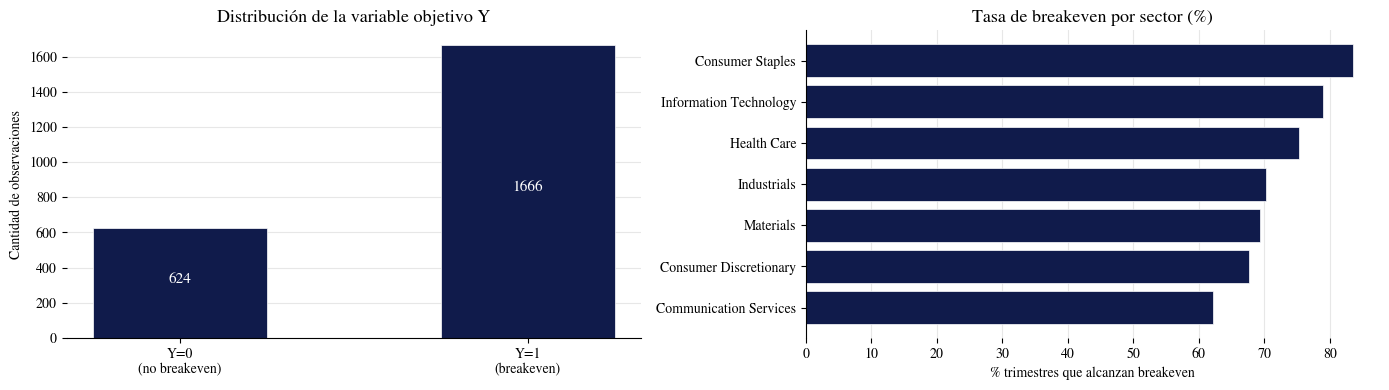

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico 1 — distribución Y (barras verticales)
estilo_ax(axes[0], "vertical")
conteo_y = df_modelo["Y"].value_counts().sort_index()
axes[0].bar(["Y=0\n(no breakeven)", "Y=1\n(breakeven)"],
            conteo_y.values,
            color=juan_colors[0],
            edgecolor="white", linewidth=0.5, width=0.5)
axes[0].set_title("Distribución de la variable objetivo Y", fontfamily=FUENTE, fontsize=13)
axes[0].set_ylabel("Cantidad de observaciones", fontfamily=FUENTE)
for i, v in enumerate(conteo_y.values):
    axes[0].text(i, v / 2, str(v), ha="center", fontfamily=FUENTE, 
                 fontsize=11, color='white')

# Gráfico 2 — tasa de breakeven por sector (barras horizontales)
estilo_ax(axes[1], "horizontal")
tasa_sector = df_modelo.groupby("sector")["Y"].mean().sort_values()
axes[1].barh(tasa_sector.index, tasa_sector.values * 100,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Tasa de breakeven por sector (%)", fontfamily=FUENTE, fontsize=13)
axes[1].set_xlabel("% trimestres que alcanzan breakeven", fontfamily=FUENTE)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)

plt.tight_layout()
plt.show()

### Hallazgo sobre el desbalance de clases

El dataset presenta un desbalance de ~73% positivos vs ~27% negativos. Este resultado refleja una característica estructural del universo de estudio: las empresas del S&P 500 son compañías grandes y consolidadas que, cuando tienen un trimestre de FCF negativo, tienden a recuperarse rápidamente.

Este desbalance se documentará como un hallazgo metodológico y se manejará en el modelado mediante **class weights** — sin manipular los datos, sino ajustando la penalización del modelo para que aprenda igual de los casos minoritarios.

## 8. Análisis del FCF negativo

Antes de construir las variables derivadas, analizamos la distribución de la quema de caja para entender la naturaleza de las observaciones del modelo.

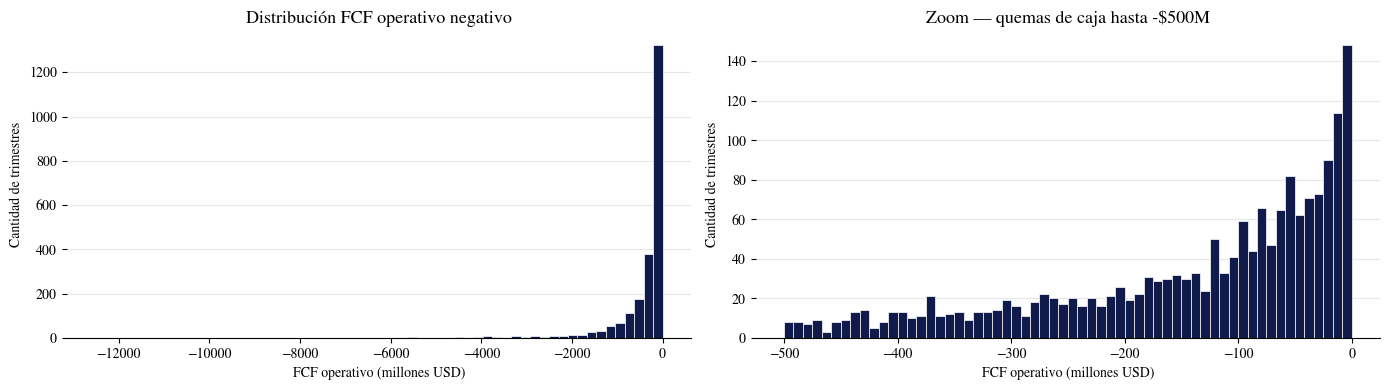

Quema leve    (> -$100M):       917 trimestres (40.0%)
Quema moderada (-$100M a -$1B): 1,135 trimestres (49.6%)
Quema severa  (< -$1B):         238 trimestres (10.4%)


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    estilo_ax(ax, "vertical")

fcf_neg = df_modelo["fcf_operativo"]

# Gráfico 1 — distribución completa
axes[0].hist(fcf_neg / 1e6, bins=60,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribución FCF operativo negativo", fontfamily=FUENTE, fontsize=13)
axes[0].set_xlabel("FCF operativo (millones USD)", fontfamily=FUENTE)
axes[0].set_ylabel("Cantidad de trimestres", fontfamily=FUENTE)

# Gráfico 2 — zoom en quemas leves
fcf_leve = fcf_neg[fcf_neg >= -500e6]
axes[1].hist(fcf_leve / 1e6, bins=60,
             color=juan_colors[0], edgecolor="white", linewidth=0.5)
axes[1].set_title("Zoom — quemas de caja hasta -$500M", fontfamily=FUENTE, fontsize=13)
axes[1].set_xlabel("FCF operativo (millones USD)", fontfamily=FUENTE)
axes[1].set_ylabel("Cantidad de trimestres", fontfamily=FUENTE)

plt.tight_layout()
plt.show()

leve     = (fcf_neg > -100e6).sum()
moderada = ((fcf_neg <= -100e6) & (fcf_neg > -1e9)).sum()
severa   = (fcf_neg <= -1e9).sum()

print(f"Quema leve    (> -$100M):       {leve:,} trimestres ({leve/len(fcf_neg)*100:.1f}%)")
print(f"Quema moderada (-$100M a -$1B): {moderada:,} trimestres ({moderada/len(fcf_neg)*100:.1f}%)")
print(f"Quema severa  (< -$1B):         {severa:,} trimestres ({severa/len(fcf_neg)*100:.1f}%)")

## 9. Ingeniería de features

Las variables descargadas de la SEC son valores absolutos en dólares. Para el modelo de machine learning son más útiles variables relativas y derivadas que capturan la dinámica del negocio independientemente del tamaño de la empresa.

Se construyen 7 variables derivadas:

| Variable | Fórmula | Interpretación |
|---|---|---|
| `burn_rate` | `\|FCF operativo\|` | Cuánto quema por trimestre (valor positivo) |
| `runway` | `caja / burn_rate` | Trimestres de caja disponibles |
| `capital_trabajo` | `activos_corrientes - pasivos_corrientes` | Liquidez neta de corto plazo |
| `margen_bruto` | `utilidad_bruta / ingresos` | Eficiencia del negocio core |
| `margen_operativo` | `utilidad_operativa / ingresos` | Eficiencia operativa total |
| `ratio_id` | `gastos_id / ingresos` | Intensidad de inversión en innovación |
| `ratio_deuda` | `deuda_largo_plazo / activos_totales` | Apalancamiento financiero |

### Tratamiento de outliers — winsorización

Las variables derivadas pueden generar valores extremos — por ejemplo, `runway` puede ser astronómico si la empresa tiene caja elevada y quema muy poca. En lugar de eliminar esos registros (lo que sesgaría el dataset), aplicamos **winsorización**: los valores por debajo del percentil 1 y por encima del percentil 99 se reemplazan por esos límites. Esto preserva la información de los casos extremos sin que distorsionen el entrenamiento.

In [64]:
df_modelo = df_modelo.copy()

# Construir variables derivadas
df_modelo["burn_rate"]        = df_modelo["fcf_operativo"].abs()
df_modelo["runway"]           = df_modelo["caja"] / df_modelo["burn_rate"]
df_modelo["capital_trabajo"]  = df_modelo["activos_corrientes"] - df_modelo["pasivos_corrientes"]
df_modelo["margen_bruto"]     = df_modelo["utilidad_bruta"] / df_modelo["ingresos"]
df_modelo["margen_operativo"] = df_modelo["utilidad_operativa"] / df_modelo["ingresos"]
df_modelo["ratio_id"]         = df_modelo["gastos_id"] / df_modelo["ingresos"]
df_modelo["ratio_deuda"]      = df_modelo["deuda_largo_plazo"] / df_modelo["activos_totales"]

# Winsorización al percentil 1-99
variables_winsorizables = [
    "runway", "burn_rate", "capital_trabajo",
    "margen_bruto", "margen_operativo", "ratio_id", "ratio_deuda"
]

for var in variables_winsorizables:
    p01 = df_modelo[var].quantile(0.01)
    p99 = df_modelo[var].quantile(0.99)
    df_modelo[var] = df_modelo[var].clip(lower=p01, upper=p99)

print("Variables derivadas creadas y winsorizadas.")
print(f"Shape final: {df_modelo.shape}")

Variables derivadas creadas y winsorizadas.
Shape final: (2290, 32)


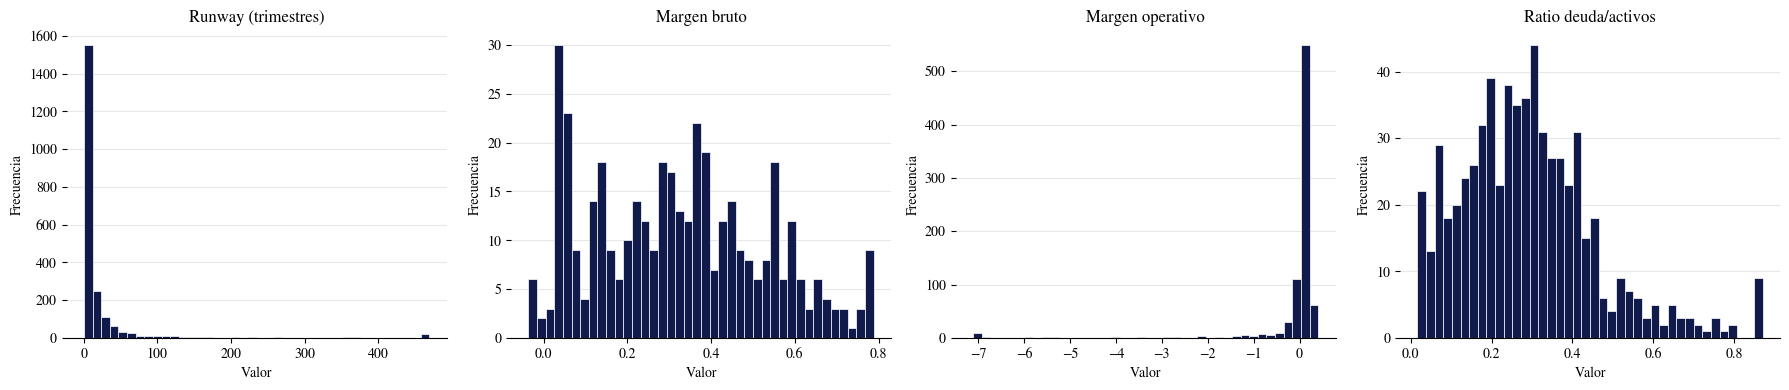

In [65]:
# Gráfico — distribución de las variables derivadas clave
vars_plot = ["runway", "margen_bruto", "margen_operativo", "ratio_deuda"]
titulos   = ["Runway (trimestres)", "Margen bruto", "Margen operativo", "Ratio deuda/activos"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, var, titulo in zip(axes, vars_plot, titulos):
    estilo_ax(ax, "vertical")
    ax.hist(df_modelo[var].dropna(), bins=40,
            color=juan_colors[0], edgecolor="white", linewidth=0.5)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=12)
    ax.set_xlabel("Valor", fontfamily=FUENTE)
    ax.set_ylabel("Frecuencia", fontfamily=FUENTE)

plt.tight_layout()
plt.show()

## 10. Guardar dataset final

El dataset procesado se guarda en `datos/procesados/` y queda listo para el Cuaderno 3 de modelado.

In [66]:
ruta = "../datos/procesados/dataset_modelo.csv"
df_modelo.to_csv(ruta, index=False)

tamano_kb = Path(ruta).stat().st_size / 1024
print(f"Guardado: {ruta}")
print(f"Tamaño: {tamano_kb:.0f} KB")
print(f"\nResumen del dataset:")
print(f"  Observaciones totales:      {len(df_modelo):,}")
print(f"  Empresas representadas:     {df_modelo['ticker'].nunique()}")
print(f"  Variables (features + Y):   {df_modelo.shape[1]}")
print(f"  Período cubierto:           {df_modelo['end'].min().date()} → {df_modelo['end'].max().date()}")
print(f"  Tasa de breakeven (Y=1):    {df_modelo['Y'].mean()*100:.1f}%")

Guardado: ../datos/procesados/dataset_modelo.csv
Tamaño: 611 KB

Resumen del dataset:
  Observaciones totales:      2,290
  Empresas representadas:     313
  Variables (features + Y):   32
  Período cubierto:           2008-06-30 → 2025-01-31
  Tasa de breakeven (Y=1):    72.8%
